<a href="https://colab.research.google.com/github/CMILINAZZO/medical-llm-self-bias-audit/blob/main/notebooks/04_analysis_visuals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import os
import shutil
from pathlib import Path
import pandas as pd
from google.colab import userdata

# 1. Configuration
GITHUB_USERNAME = "CMILINAZZO"
REPO_NAME = "medical-llm-self-bias-audit"
REPO_ROOT = Path(f"/content/{REPO_NAME}")

# 2. Clean clone sequence
if REPO_ROOT.exists() and not (REPO_ROOT / ".git").exists():
    shutil.rmtree(REPO_ROOT)

if not REPO_ROOT.exists():
    print("Cloning fresh copy of the repository...")
    !git clone https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git
else:
    print("Repository found. Pulling latest updates...")
    os.chdir(REPO_ROOT)
    !git pull

# 3. Synchronize Working Directory
os.chdir(REPO_ROOT / "notebooks")
print(f"\\n Active Working Directory synchronized to: {os.getcwd()}")

Cloning fresh copy of the repository...
Cloning into 'medical-llm-self-bias-audit'...
remote: Enumerating objects: 176, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 176 (delta 114), reused 9 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (176/176), 659.45 KiB | 3.73 MiB/s, done.
Resolving deltas: 100% (114/114), done.
\n Active Working Directory synchronized to: /content/medical-llm-self-bias-audit/notebooks


In [2]:
# Cell 2: Load & Clean the Data

# 1. Define standard paths
OUTPUT_PATH = "../outputs/final_audit_matrix.csv"

# 2. Load the matrix
df_audit = pd.read_csv(OUTPUT_PATH)

# 3. Clean up the raw memory objects into readable judge names
def clean_judge_name(name):
    name = str(name).lower()
    if 'anthropic' in name: return 'claude-sonnet-4-6'
    if 'google' in name: return 'gemini-2.5-pro'
    return name

df_audit['judge_model'] = df_audit['judge_model'].apply(clean_judge_name)

print(f" Data loaded and cleaned! Total evaluations: {len(df_audit)}")
print("\\nJudge Distribution:")
print(df_audit['judge_model'].value_counts())

 Data loaded and cleaned! Total evaluations: 507
\nJudge Distribution:
judge_model
gpt-4o               250
claude-sonnet-4-6    170
gemini-2.5-pro        87
Name: count, dtype: int64


**IMPORTANT NOTE:** The following Cell 3 only needs to be run if you had to run cells 7-8 in Notebook 3.

In [4]:
# Cell 3: Load & Clean the Data

# 1. Load both files
df_salvaged = pd.read_csv('../outputs/salvaged_audit_matrix.csv')
df_final = pd.read_csv('../outputs/final_audit_matrix.csv')

# 2. Clean up the raw memory objects into readable judge names
def clean_judge_name(name):
    name = str(name).lower()
    if 'anthropic' in name: return 'claude-sonnet-4-6'
    if 'google' in name: return 'gemini-2.5-pro'
    return name

df_salvaged['judge_model'] = df_salvaged['judge_model'].apply(clean_judge_name)
df_final['judge_model'] = df_final['judge_model'].apply(clean_judge_name)

# 3. Combine, prioritize the final matrix (since it has ROUGE-L), and drop duplicates
df_combined = pd.concat([df_final, df_salvaged], ignore_index=True)
df_master = df_combined.drop_duplicates(subset=['pmid', 'student_model', 'judge_model'], keep='first')

print(f"Yay! Total unique evaluations squeezed out: {len(df_master)}")
print("\nFinal Judge Distribution:")
print(df_master['judge_model'].value_counts())

Yay! Total unique evaluations squeezed out: 571

Final Judge Distribution:
judge_model
gpt-4o               299
claude-sonnet-4-6    170
gemini-2.5-pro       102
Name: count, dtype: int64


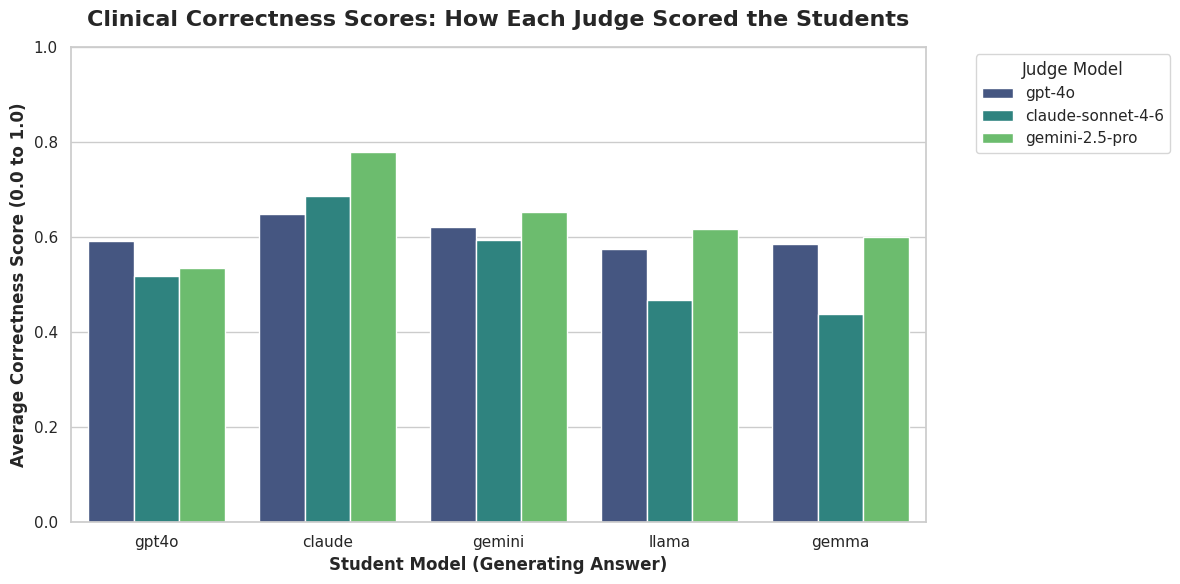

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cell 4: Correctness by Judge - Grouped Bar Chart

# Set the visual style for the charts
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create a grouped bar chart
ax = sns.barplot(
    data=df_master,
    x='student_model',
    y='correctness_score',
    hue='judge_model',
    palette='viridis',
    errorbar=None # Turns off the confidence interval lines for a cleaner look
)

# Formatting the chart
plt.title('Clinical Correctness Scores: How Each Judge Scored the Students', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Student Model (Generating Answer)', fontsize=12, fontweight='bold')
plt.ylabel('Average Correctness Score (0.0 to 1.0)', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0) # Lock the y-axis to a 0-1 scale
plt.legend(title='Judge Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the chart
plt.show()